# Synthetic Raster-to-Vector Notebook

This notebook creates random synthetic training/test data containing up to **5 straight vectors** per image. Each vector is rendered as a **1 px black line on a white 64×64 raster image**.

The vectorisation algorithm then:

1. Reads every pixel.
2. Treats pixels that are at least **50% black** as active dots.
3. Groups connected dots into line components.
4. Breaks lines at crossings/intersections.
5. Fits one or more average straight vectors through the dot groups.
6. Converts predicted vectors back to raster.
7. Displays **10 random examples** showing input raster, detected dots, predicted vectors, and input-vs-output comparison.

This is not a deep learning model. It is a classical pixel-based vectorisation pipeline designed to make the process visible and easy to debug.


In [1]:
# Cell 1: Imports and configuration

import math
import random
from dataclasses import dataclass
from typing import List

import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 64
MAX_LINES = 5
LINE_WIDTH = 1
BLACK_THRESHOLD = 0.50

N_TRAIN = 500
N_TEST = 100
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Notebook ready")


Notebook ready


In [2]:
# Cell 2: Helper data structure

@dataclass
class VectorLine:
    x1: int
    y1: int
    x2: int
    y2: int

    def as_tuple(self):
        return (self.x1, self.y1, self.x2, self.y2)


In [3]:
# Cell 3: Bresenham line rasterisation

# Images use 0.0 = black and 1.0 = white.
# Coordinates are x,y but numpy arrays are indexed as image[y, x].

def bresenham_points(x1, y1, x2, y2):
    """Return integer pixel coordinates for a 1 px line."""
    points = []

    dx = abs(x2 - x1)
    dy = -abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx + dy

    x, y = x1, y1
    while True:
        points.append((x, y))
        if x == x2 and y == y2:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy

    return points


def draw_line(image, line: VectorLine, value=0.0):
    """Draw a 1 px black line on a white image."""
    for x, y in bresenham_points(line.x1, line.y1, line.x2, line.y2):
        if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]:
            image[y, x] = value
    return image


def rasterise_vectors(lines: List[VectorLine], img_size=IMG_SIZE):
    image = np.ones((img_size, img_size), dtype=np.float32)
    for line in lines:
        image = draw_line(image, line, value=0.0)
    return image


In [4]:
# Cell 4: Generate synthetic vectors and raster images

# This generates random lines with random length.
# A minimum length avoids tiny lines that are hard to inspect visually.

def random_line(img_size=IMG_SIZE, min_length=8):
    while True:
        x1 = np.random.randint(0, img_size)
        y1 = np.random.randint(0, img_size)
        x2 = np.random.randint(0, img_size)
        y2 = np.random.randint(0, img_size)
        length = math.hypot(x2 - x1, y2 - y1)
        if length >= min_length:
            return VectorLine(x1, y1, x2, y2)


def make_sample(max_lines=MAX_LINES, img_size=IMG_SIZE):
    n_lines = np.random.randint(1, max_lines + 1)
    lines = [random_line(img_size=img_size) for _ in range(n_lines)]
    raster = rasterise_vectors(lines, img_size=img_size)
    return {"image": raster, "true_vectors": lines}


def make_dataset(n_samples):
    return [make_sample() for _ in range(n_samples)]

train_set = make_dataset(N_TRAIN)
test_set = make_dataset(N_TEST)

print(f"Training samples: {len(train_set)}")
print(f"Test samples: {len(test_set)}")
print(f"Example true vectors: {[v.as_tuple() for v in test_set[0]['true_vectors']]}")


Training samples: 500
Test samples: 100
Example true vectors: [(27, 45, 31, 61), (4, 63, 37, 9), (39, 63, 45, 23)]


In [5]:
# Cell 5: Pixel thresholding

# A pixel value of 0 is black and 1 is white.
# 50% black means pixel darkness >= 0.50.
# darkness = 1 - pixel_value.

def image_to_dot_mask(image, black_threshold=BLACK_THRESHOLD):
    darkness = 1.0 - image
    return darkness >= black_threshold

example_mask = image_to_dot_mask(test_set[0]["image"])
print("Active dot pixels:", int(example_mask.sum()))


Active dot pixels: 113


In [6]:
# Cell 6: Break at intersections and endpoints

# A crossing/intersection is detected where a dot has more than two active neighbours.
# Endpoints have one active neighbour.
# We remove intersections from the graph before tracing, which breaks crossing lines into segments.

NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def active_neighbours(mask, x, y):
    h, w = mask.shape
    found = []
    for dx, dy in NEIGHBOURS_8:
        nx, ny = x + dx, y + dy
        if 0 <= nx < w and 0 <= ny < h and mask[ny, nx]:
            found.append((nx, ny))
    return found


def find_special_points(mask):
    endpoints = set()
    intersections = set()

    ys, xs = np.where(mask)
    for x, y in zip(xs, ys):
        n = len(active_neighbours(mask, x, y))
        if n == 1:
            endpoints.add((x, y))
        elif n > 2:
            intersections.add((x, y))

    return endpoints, intersections


def connected_components_without_intersections(mask, intersections):
    usable = mask.copy()
    for x, y in intersections:
        usable[y, x] = False

    visited = np.zeros_like(usable, dtype=bool)
    components = []

    ys, xs = np.where(usable)
    for start_x, start_y in zip(xs, ys):
        if visited[start_y, start_x]:
            continue

        stack = [(start_x, start_y)]
        visited[start_y, start_x] = True
        component = []

        while stack:
            x, y = stack.pop()
            component.append((x, y))
            for nx, ny in active_neighbours(usable, x, y):
                if not visited[ny, nx]:
                    visited[ny, nx] = True
                    stack.append((nx, ny))

        if len(component) >= 2:
            components.append(component)

    return components


In [7]:
# Cell 7: Fit average vectors through dot groups

# Each connected component after intersection removal is fitted as a single average line.
# PCA gives the dominant direction of the dots.
# The projected min/max points become the vector endpoints.


def fit_average_line(points):
    pts = np.array(points, dtype=np.float32)
    mean = pts.mean(axis=0)

    if len(pts) == 2:
        a, b = pts[0], pts[1]
    else:
        centred = pts - mean
        _, _, vh = np.linalg.svd(centred, full_matrices=False)
        direction = vh[0]
        projections = centred @ direction
        a = mean + projections.min() * direction
        b = mean + projections.max() * direction

    x1, y1 = np.clip(np.round(a), 0, IMG_SIZE - 1).astype(int)
    x2, y2 = np.clip(np.round(b), 0, IMG_SIZE - 1).astype(int)
    return VectorLine(int(x1), int(y1), int(x2), int(y2))


def vectorise_image(image, black_threshold=BLACK_THRESHOLD, min_component_pixels=3):
    dot_mask = image_to_dot_mask(image, black_threshold=black_threshold)
    endpoints, intersections = find_special_points(dot_mask)
    components = connected_components_without_intersections(dot_mask, intersections)

    predicted_vectors = []
    for component in components:
        if len(component) >= min_component_pixels:
            predicted_vectors.append(fit_average_line(component))

    output_raster = rasterise_vectors(predicted_vectors, img_size=image.shape[0])

    return {
        "dot_mask": dot_mask,
        "endpoints": endpoints,
        "intersections": intersections,
        "components": components,
        "predicted_vectors": predicted_vectors,
        "output_raster": output_raster,
    }


In [8]:
# Cell 8: Simple raster comparison metrics

# These metrics compare the input raster and the predicted raster.
# They are useful for quick testing, but visual inspection is still important.


def raster_metrics(input_image, output_image):
    input_black = input_image < 0.5
    output_black = output_image < 0.5

    intersection = np.logical_and(input_black, output_black).sum()
    union = np.logical_or(input_black, output_black).sum()

    iou = intersection / union if union else 1.0
    precision = intersection / output_black.sum() if output_black.sum() else 0.0
    recall = intersection / input_black.sum() if input_black.sum() else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "input_black_pixels": int(input_black.sum()),
        "output_black_pixels": int(output_black.sum()),
    }

result = vectorise_image(test_set[0]["image"])
print(raster_metrics(test_set[0]["image"], result["output_raster"]))
print("Predicted vectors:", [v.as_tuple() for v in result["predicted_vectors"]])


{'iou': np.float64(0.9482758620689655), 'precision': np.float64(0.9734513274336283), 'recall': np.float64(0.9734513274336283), 'f1': np.float64(0.9734513274336283), 'input_black_pixels': 113, 'output_black_pixels': 113}
Predicted vectors: [(37, 9, 4, 63), (39, 63, 45, 23), (27, 45, 31, 61)]


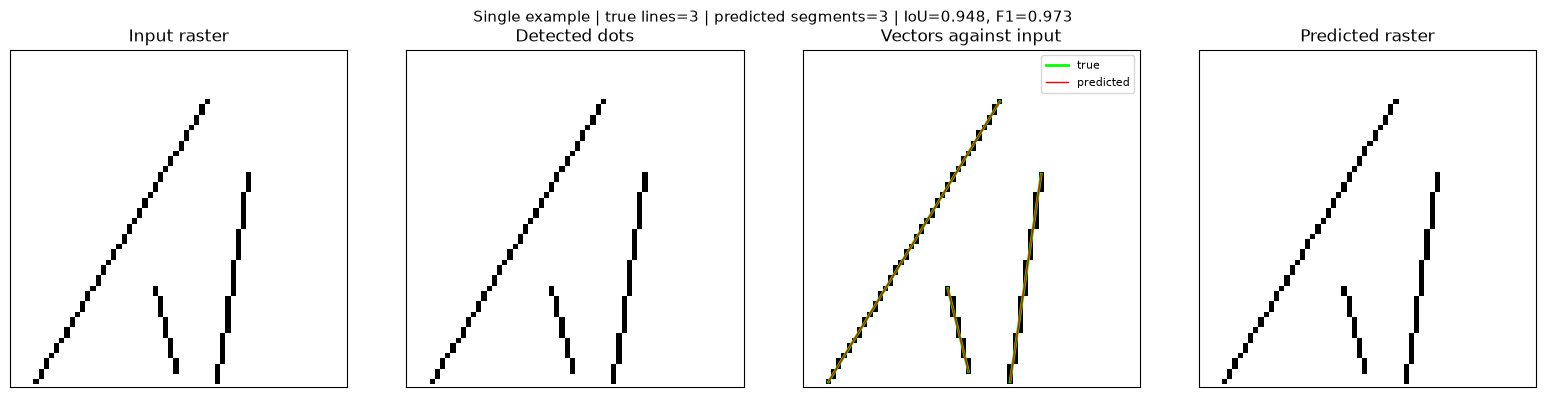

In [9]:
# Cell 9: Visualisation helpers


def plot_vectors_on_axis(ax, vectors, colour="red", linewidth=1.5, label=None):
    for i, line in enumerate(vectors):
        ax.plot(
            [line.x1, line.x2],
            [line.y1, line.y2],
            linewidth=linewidth,
            color=colour,
            label=label if i == 0 else None,
        )


def show_result(sample, title=""):
    image = sample["image"]
    true_vectors = sample["true_vectors"]
    result = vectorise_image(image)
    predicted_vectors = result["predicted_vectors"]
    metrics = raster_metrics(image, result["output_raster"])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Input raster")

    axes[1].imshow(result["dot_mask"], cmap="gray_r")
    axes[1].set_title("Detected dots")
    if result["intersections"]:
        xs = [p[0] for p in result["intersections"]]
        ys = [p[1] for p in result["intersections"]]
        axes[1].scatter(xs, ys, marker="x", s=40, label="intersections")
        axes[1].legend(loc="upper right", fontsize=8)

    axes[2].imshow(image, cmap="gray", vmin=0, vmax=1)
    plot_vectors_on_axis(axes[2], true_vectors, colour="lime", linewidth=2, label="true")
    plot_vectors_on_axis(axes[2], predicted_vectors, colour="red", linewidth=1, label="predicted")
    axes[2].set_title("Vectors against input")
    axes[2].legend(loc="upper right", fontsize=8)

    axes[3].imshow(result["output_raster"], cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Predicted raster")

    for ax in axes:
        ax.set_xlim(-1, IMG_SIZE)
        ax.set_ylim(IMG_SIZE, -1)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"{title} | true lines={len(true_vectors)} | predicted segments={len(predicted_vectors)} | "
        f"IoU={metrics['iou']:.3f}, F1={metrics['f1']:.3f}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

show_result(test_set[0], title="Single example")


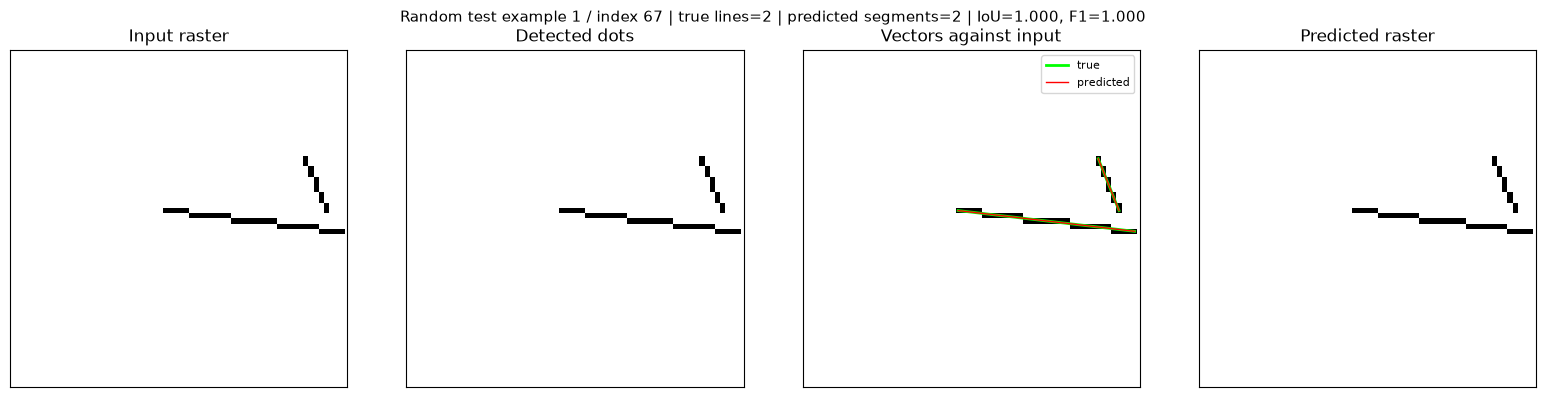

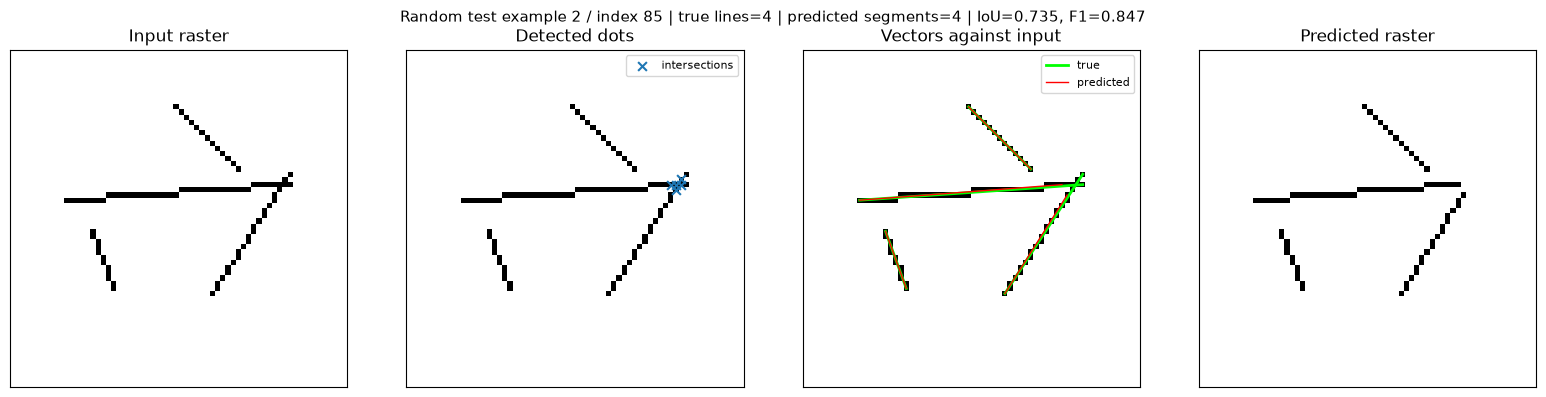

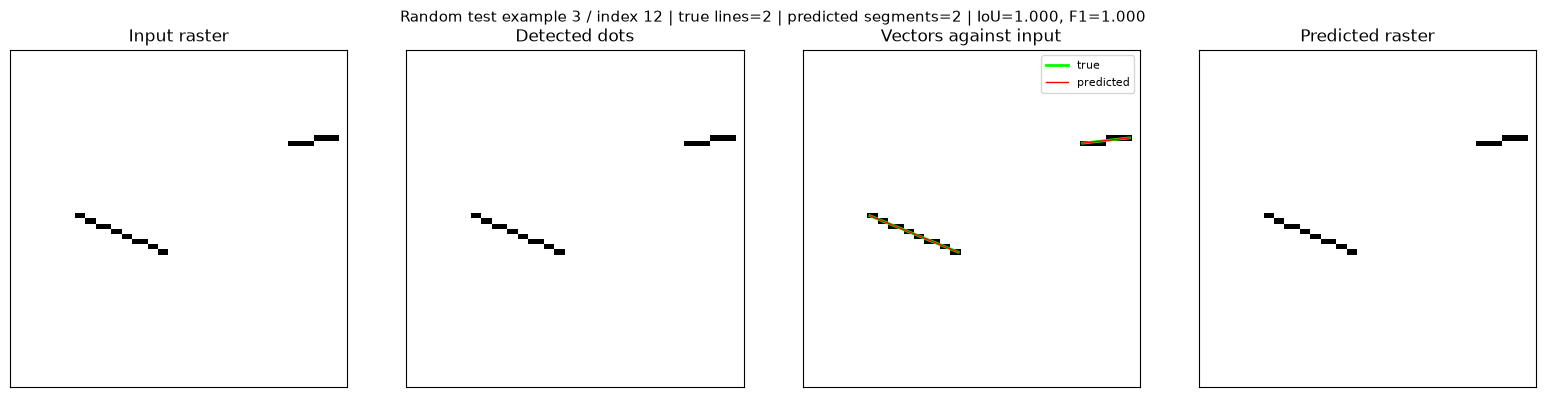

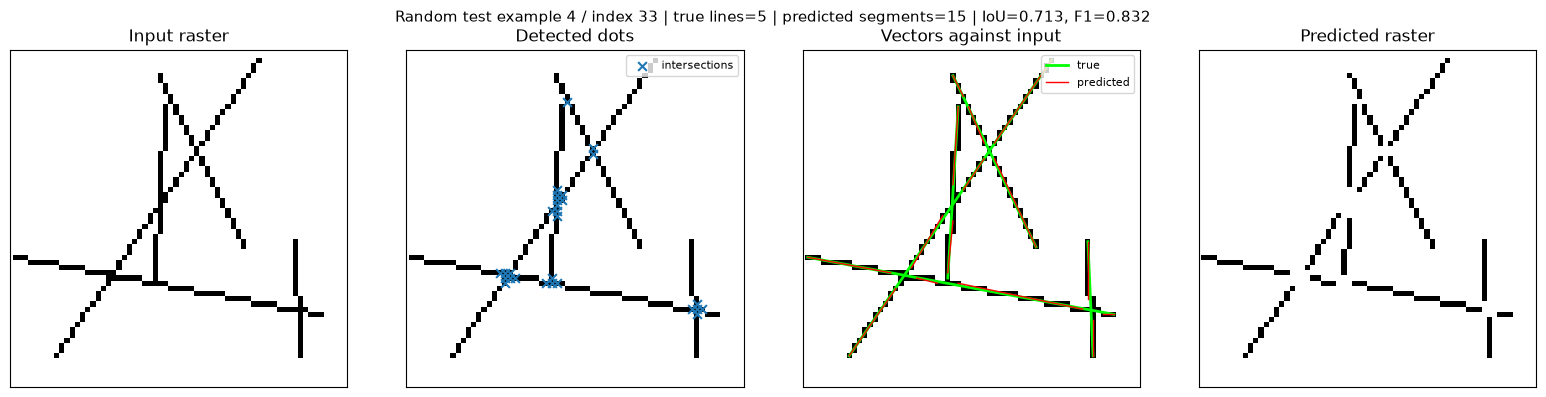

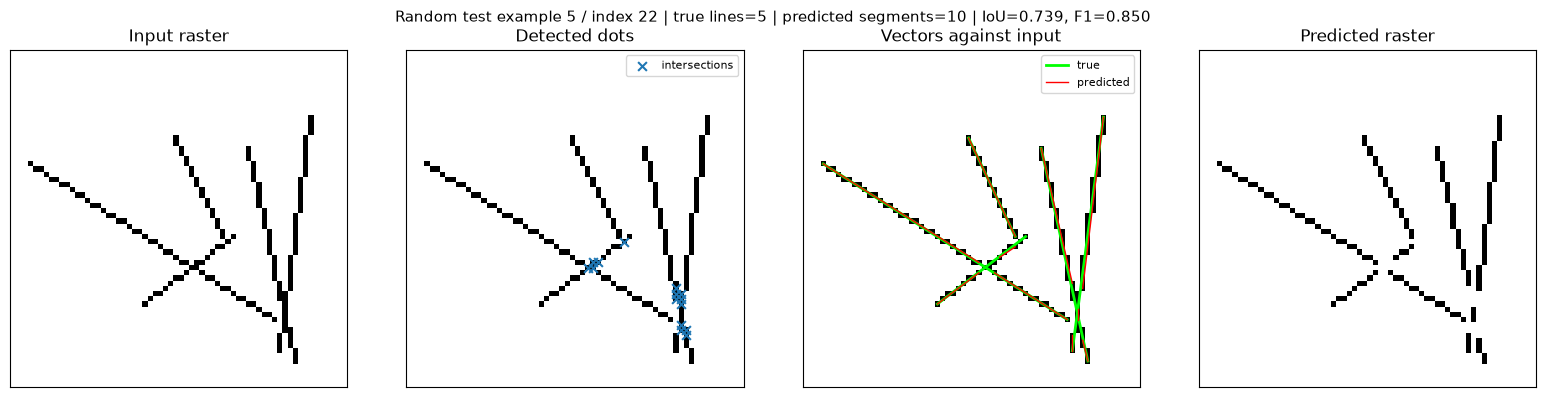

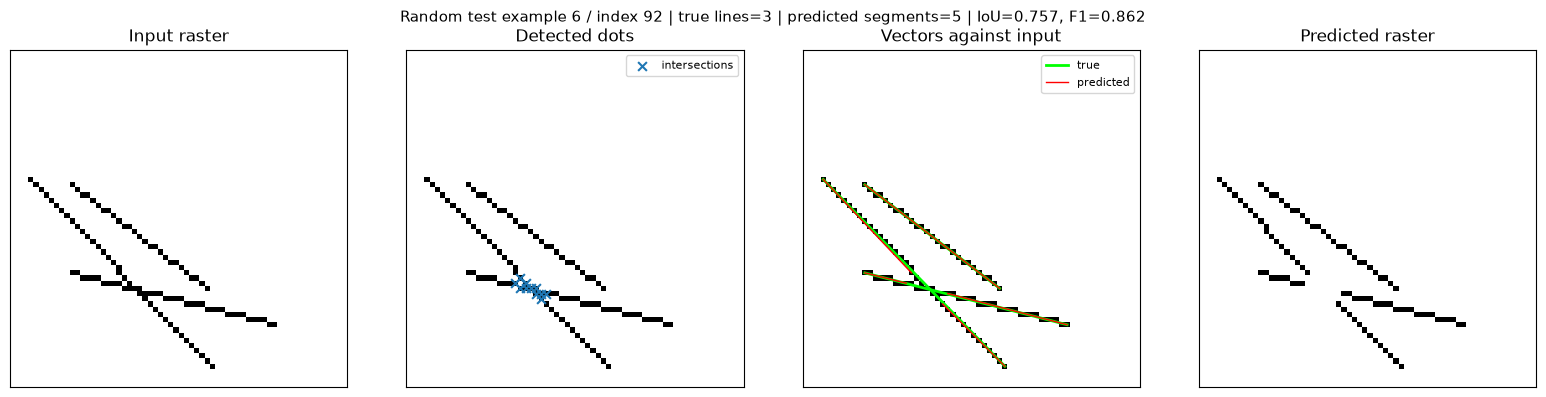

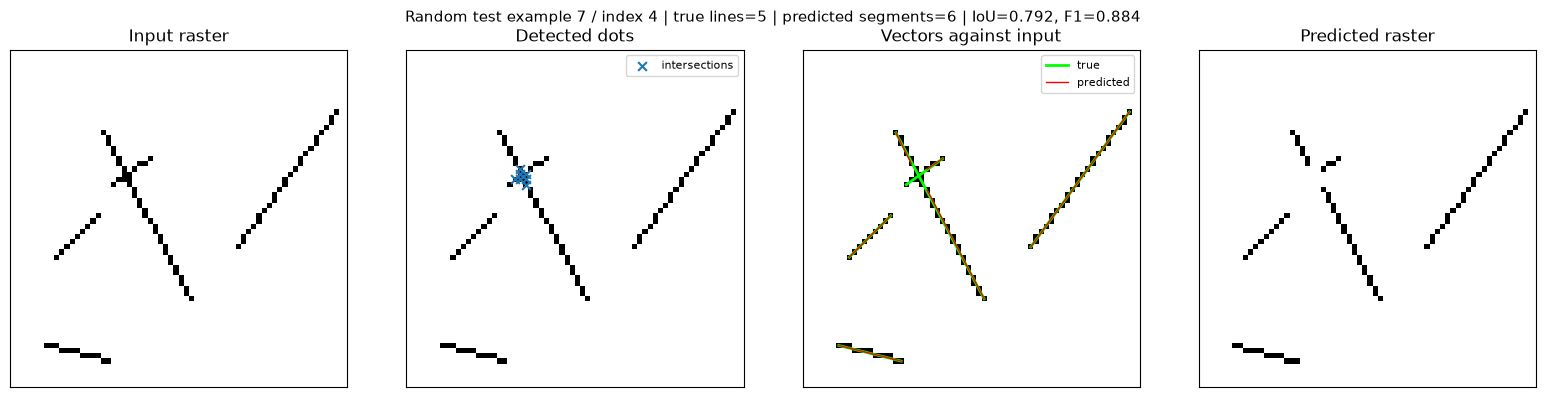

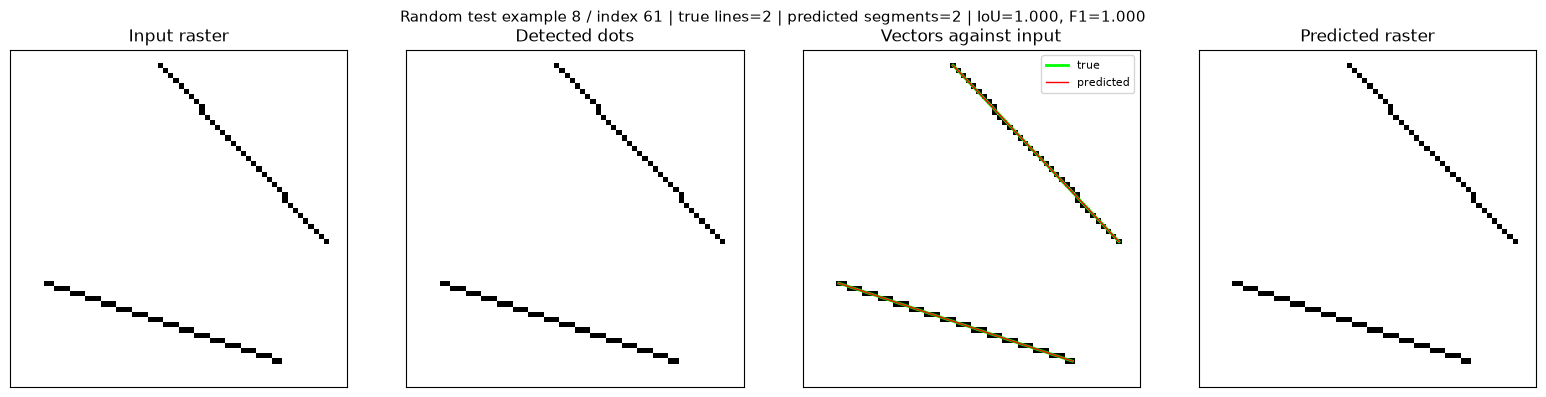

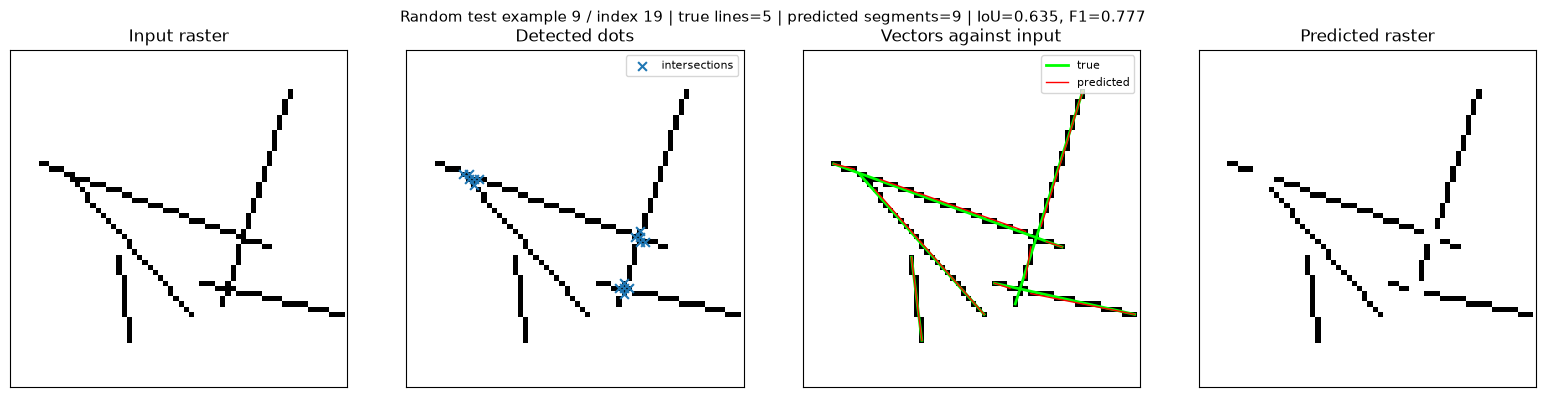

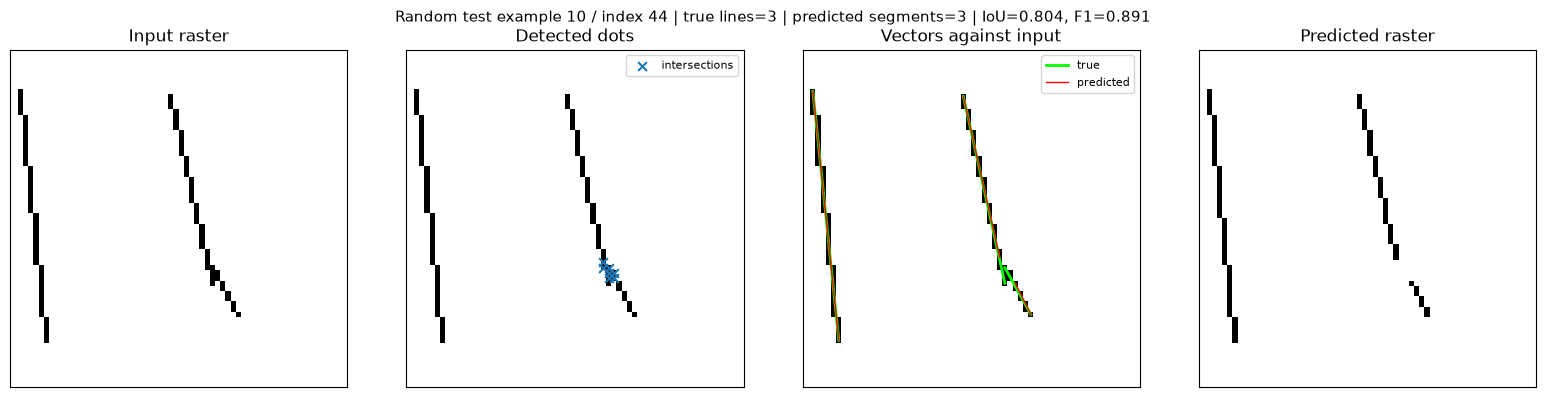

In [10]:
# Cell 10: Display 10 random test examples

random_indices = np.random.choice(len(test_set), size=10, replace=False)

for i, idx in enumerate(random_indices, start=1):
    show_result(test_set[idx], title=f"Random test example {i} / index {idx}")


In [11]:
# Cell 11: Dataset arrays for later machine learning experiments

# These arrays are ready if you later want to train an ML model.
# X contains raster images.
# y_true_vectors stores the original vector labels as variable-length lists.

X_train = np.stack([sample["image"] for sample in train_set])
X_test = np.stack([sample["image"] for sample in test_set])

y_train_vectors = [[v.as_tuple() for v in sample["true_vectors"]] for sample in train_set]
y_test_vectors = [[v.as_tuple() for v in sample["true_vectors"]] for sample in test_set]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("First y_test vector labels:", y_test_vectors[0])


X_train shape: (500, 64, 64)
X_test shape: (100, 64, 64)
First y_test vector labels: [(27, 45, 31, 61), (4, 63, 37, 9), (39, 63, 45, 23)]


## Notes

This notebook deliberately uses a transparent classical algorithm rather than a neural network, because your description is pixel-threshold based:

- black enough pixel → dot
- connected dots → line segments
- intersections → break points
- average dot direction → vector line

Because crossing lines are explicitly broken, the predicted result may contain more vector segments than the original number of generated lines. That is expected.
